# 01 · Dataset preparation

**Goal:** build a leak-free image dataset in `data/train`, `data/val`, `data/test`.

**Dataset:** NIH Malaria Cell Images (U.S. National Library of Medicine, Rajaraman et al., 2018): 27,558 microscope images of single red blood cells, half `Parasitized` (malaria parasite visible) and half `Uninfected`. We download the public Kaggle copy `iarunava/cell-images-for-detecting-malaria` (about 350 MB).

## 1. Install dependencies

In [1]:
%pip install -q kagglehub opencv-python pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Project folder

In [2]:
# Run this cell first, every time you open the notebook.
import os, sys
from pathlib import Path

if "google.colab" in sys.modules:                       # Google Colab
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/MalariaScanAI")  # where you unzipped the project
else:                                                   # your own laptop
    ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print("Project folder:", ROOT)

Project folder: c:\Users\VOTHY VYSAL\Documents\MalariaScanAI


## 3. Import libraries and configuration

In [3]:
import random, shutil
import cv2
import pandas as pd
import matplotlib.pyplot as plt

MAX_PER_CLASS = None    # images used per class. Smaller = faster training. None = use all 13,779.
SEED = 42
DATA = ROOT / "data"

## 4. Check GPU

In [4]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Device: cuda
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
GPU memory: 4.0 GB


## 5. Download the dataset

If it asks for a Kaggle login, create a free Kaggle account and follow the printed instructions.

In [5]:
import kagglehub
SRC = Path(kagglehub.dataset_download("iarunava/cell-images-for-detecting-malaria"))
print("Downloaded to:", SRC)

100%|██████████| 675M/675M [03:15<00:00, 3.62MB/s] 

Extracting files...


Downloaded to: C:\Users\VOTHY VYSAL\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1


## 6. Explore the dataset

Each file name starts with a code for the **blood slide** the cell was cut from, for example `C100P61ThinF_IMG_..._cell_162.png`. We keep that code as `slide`, because cells from one slide look alike and must stay together when we split.

In [6]:
# The Kaggle copy contains the same folders twice; take the first "Parasitized" folder found.
base = sorted(SRC.rglob("Parasitized"), key=lambda p: len(p.parts))[0].parent
print("Image folder:", base)

rows = []
for folder, label in (("Parasitized", "PARASITIZED"), ("Uninfected", "UNINFECTED")):
    for path in sorted((base / folder).glob("*.png")):
        slide = path.name.split("_")[0].lower().replace("thinf", "")
        rows.append({"label": label, "slide": slide, "path": str(path)})
all_images = pd.DataFrame(rows)

print("Total images:", len(all_images))
print("Images per class:")
print(all_images.label.value_counts())
print("Number of blood slides:", all_images.slide.nunique())
h, w = cv2.imread(all_images.path[0]).shape[:2]
print(f"Example image size: {w} x {h} pixels (sizes vary; they are resized to 224 x 224 during training)")

Image folder: C:\Users\VOTHY VYSAL\.cache\kagglehub\datasets\iarunava\cell-images-for-detecting-malaria\versions\1\cell_images
Total images: 27558
Images per class:
label
PARASITIZED    13779
UNINFECTED     13779
Name: count, dtype: int64
Number of blood slides: 201
Example image size: 142 x 148 pixels (sizes vary; they are resized to 224 x 224 during training)


## 7. Take a balanced sample

To finish training in reasonable time on a laptop GPU we use the same number of images from each class. Set `MAX_PER_CLASS = None` in section 3 to use everything.

In [7]:
if MAX_PER_CLASS:
    df = pd.concat(g.sample(min(MAX_PER_CLASS, len(g)), random_state=SEED)
                   for _, g in all_images.groupby("label")).reset_index(drop=True)
else:
    df = all_images.copy()
classes = sorted(df.label.unique())
print("Number of classes:", len(classes))
print("Classes:", classes)
print(df.label.value_counts())

Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']
label
PARASITIZED    13779
UNINFECTED     13779
Name: count, dtype: int64


## 8. Split by blood slide (70 / 15 / 15)

**Important:** we do not split the images at random. All cells from one slide go into the same split, so the model is always tested on slides it has never seen. A random split would let near-identical cells from the same slide land in both training and test (data leakage) and make the results look better than they are.

In [8]:
slides = sorted(df.slide.unique())
random.Random(SEED).shuffle(slides)
sizes = df.slide.value_counts()

split_of, seen = {}, 0
for s in slides:                       # fill train to 70%, then val to 85%, the rest is test
    split_of[s] = "train" if seen < 0.70 * len(df) else "val" if seen < 0.85 * len(df) else "test"
    seen += sizes[s]
df["split"] = df.slide.map(split_of)

print(pd.crosstab(df.label, df.split, margins=True)[["train", "val", "test", "All"]])
print("\nSlides per split:")
print(df.groupby("split").slide.nunique()[["train", "val", "test"]])

split        train   val  test    All
label                                
PARASITIZED   9626  2676  1477  13779
UNINFECTED    9737  1647  2395  13779
All          19363  4323  3872  27558

Slides per split:
split
train    142
val       24
test      35
Name: slide, dtype: int64


## 9. Copy the images into train / val / test folders

In [9]:
for split in ("train", "val", "test"):          # start clean
    shutil.rmtree(DATA / split, ignore_errors=True)

for row in df.itertuples():
    out_dir = DATA / row.split / row.label
    out_dir.mkdir(parents=True, exist_ok=True)
    shutil.copy(row.path, out_dir / Path(row.path).name)

df.to_csv(DATA / "images.csv", index=False)
print("Images copied:", len(df))

Images copied: 27558


## 10. Check for leakage

In [10]:
ids = {s: set(g.slide) for s, g in df.groupby("split")}
assert not ids["train"] & ids["val"], "a slide is in both train and val"
assert not ids["train"] & ids["test"], "a slide is in both train and test"
assert not ids["val"] & ids["test"], "a slide is in both val and test"
print("OK: no blood slide appears in more than one split.")

OK: no blood slide appears in more than one split.


## 11. Example images

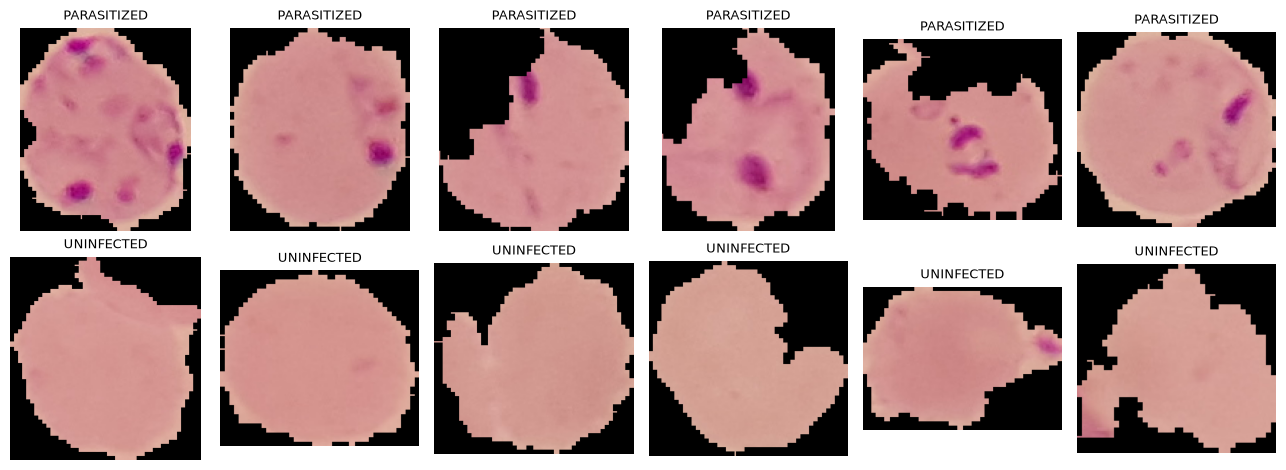

In [11]:
fig, axes = plt.subplots(len(classes), 6, figsize=(13, 2.4 * len(classes)))
for r, label in enumerate(classes):
    files = sorted((DATA / "train" / label).glob("*.png"))[:6]
    for ax, f in zip(axes[r], files):
        ax.imshow(cv2.cvtColor(cv2.imread(str(f)), cv2.COLOR_BGR2RGB))
        ax.set_title(label, fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

## 12. Summary

In [ ]:
count = lambda split: len(list((DATA / split).rglob("*.png")))
print(f"""Dataset: NIH Malaria Cell Images (Kaggle copy: iarunava/cell-images-for-detecting-malaria)
Number of classes: {len(classes)}
Classes: {classes}
Train samples: {count('train')}
Validation samples: {count('val')}
Test samples: {count('test')}
Image size: resized to 224 x 224 when loaded
GPU available: {torch.cuda.is_available()}""")

Dataset: NIH Malaria Cell Images (Kaggle copy: iarunava/cell-images-for-detecting-malaria)
Number of classes: 2
Classes: ['PARASITIZED', 'UNINFECTED']
Train samples: 19363
Validation samples: 4323
Test samples: 3872
Image size: resized to 224 x 224 when loaded
GPU available: True


: 